##### =====================================================
# Home Loan Default Prediction
### Domain: Banking & Financial Risk Analytics
##### =====================================================

### Objective:
### * Predict whether a customer will default on a loan using
### * historical financial and demographic information.

### Target:
#### 1 -> Defaulter
#### 0 -> Non-Defaulter

## Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Handling Imbalance
from imblearn.over_sampling import SMOTE

# Optional Boosting
from xgboost import XGBClassifier

#Display Settings
pd.set_option('display.max_columns', None)

print('Libraries imported Successfully')

Libraries imported Successfully


### Load Dataset


In [2]:
application = pd.read_csv(r"C:\Users\Ashik Reji\OneDrive\Documents\Datamites\Capstone Projects\HomeLoanDef\Data\application_train.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Basic Exploration

In [3]:
print("Shape :", application.shape)

application.head()

Shape : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
application.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,0.032561,-9327,-236,-8456.0,-1982,NaN,1,1,0,1,0,0,Sales staff,1.0,1,1,THURSDAY,15,0,0,0,0,0,0,Services,0.145570,0.681632,NaN,0.2021,0.0887,0.9876,0.8300,0.0202,0.22,0.1034,0.6042,0.2708,0.0594,0.1484,0.1965,0.0753,0.1095,0.1008,0.0172,0.9782,0.7125,0.0172,0.0806,0.0345,0.4583,0.0417,0.0094,0.0882,0.0853,0.0,0.0125,0.2040,0.0887,0.9876,0.8323,0.0203,0.22,0.1034,0.6042,0.2708,0.0605,0.1509,0.2001,0.0757,0.1118,reg oper account,block of flats,0.2898,"Stone, brick",No,0.0,0.0,0.0,0.0,-273.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,0.025164,-20775,365243,-4388.0,-4090,NaN,1,0,0,1,1,0,NaN,1.0,2,2,MONDAY,8,0,0,0,0,0,0,XNA,NaN,0.115992,NaN,0.0247,0.0435,0.9727,0.6260,0.0022,0.00,0.1034,0.0833,0.1250,0.0579,0.0202,0.0257,0.0000,0.0000,0.0252,0.0451,0.9727,0.6406,0.0022,0.0000,0.1034,0.0833,0.1250,0.0592,0.0220,0.0267,0.0,0.0000,0.0250,0.0435,0.9727,0.6310,0.0022,0.00,0.1034,0.0833,0.1250,0.0589,0.0205,0.0261,0.0000,0.0000,reg oper account,block of flats,0.0214,"Stone, brick",No,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Unaccompanied,Working,Higher education,Separated,House / apartment,0.005002,-14966,-7921,-6737.0,-5150,NaN,1,1,0,1,0,1,Managers,1.0,3,3,THURSDAY,9,0,0,0,0,1,1,School,0.744026,0.535722,0.218859,0.1031,0.0862,0.9816,0.7484,0.0123,0.00,0.2069,0.1667,0.2083,NaN,0.0841,0.9279,0.0000,0.0000,0.1050,0.0894,0.9816,0.7583,0.0124,0.0000,0.2069,0.1667,0.2

In [5]:
application.info("\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DA

In [6]:
application.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

### Missing Value Analysis

In [7]:
missing_values = pd.DataFrame({
    'column' : application.columns,
    'Missing_Count' : application.isnull().sum(),
    'Missing_Percentage' : (application.isnull().sum()/len(application))*100
})

missing_values = missing_values.sort_values(
    by='Missing_Percentage',
    ascending=False
)

missing_values.head(20)


,column,Missing_Count,Missing_Percentage
COMMONAREA_AVG,COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,LIVINGAPARTMENTS_MODE,210199,68.354953


### Target Variable Analysis

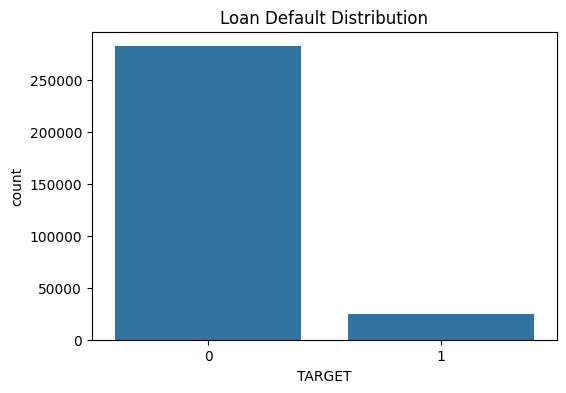

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data= application)

plt.title("Loan Default Distribution")
plt.show()

In [9]:
application['TARGET'].value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

### Exploratory Data Analysis (EDA)

##### Gender Analysis

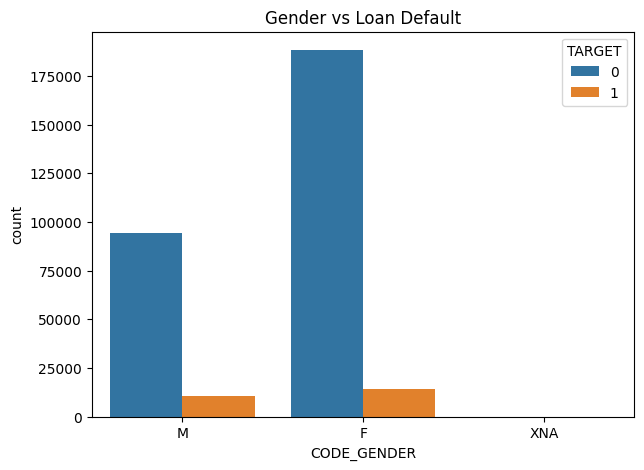

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='CODE_GENDER',
    hue='TARGET',
    data=application
)

plt.title("Gender vs Loan Default")
plt.show()

##### Income Distribution

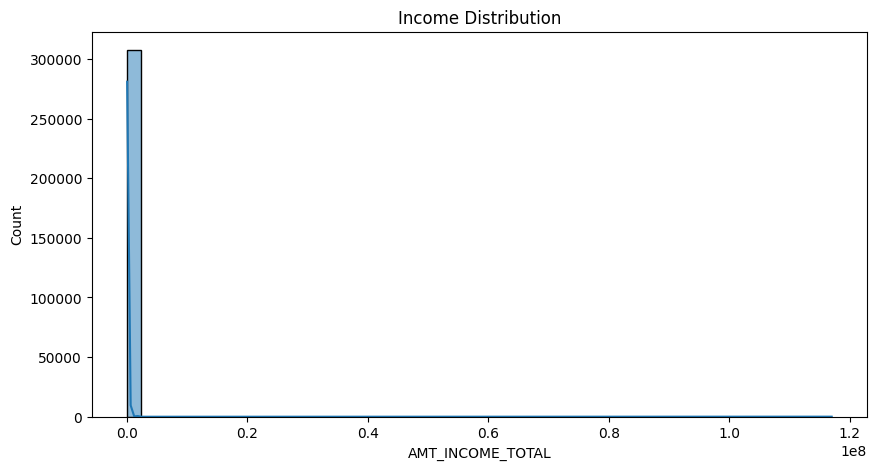

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    application['AMT_INCOME_TOTAL'],
    bins=50,
    kde=True
)

plt.title("Income Distribution")
plt.show()

##### Credit Amount

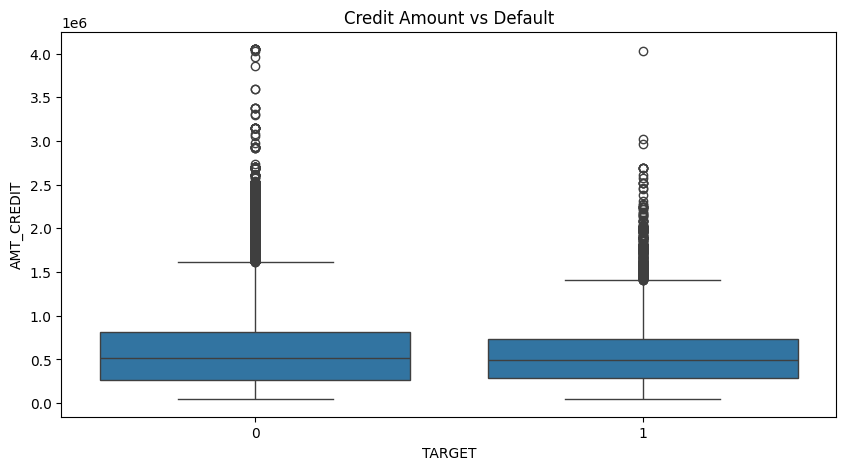

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='TARGET',
    y='AMT_CREDIT',
    data=application
)

plt.title("Credit Amount vs Default")
plt.show()

##### Correlation Heatmap

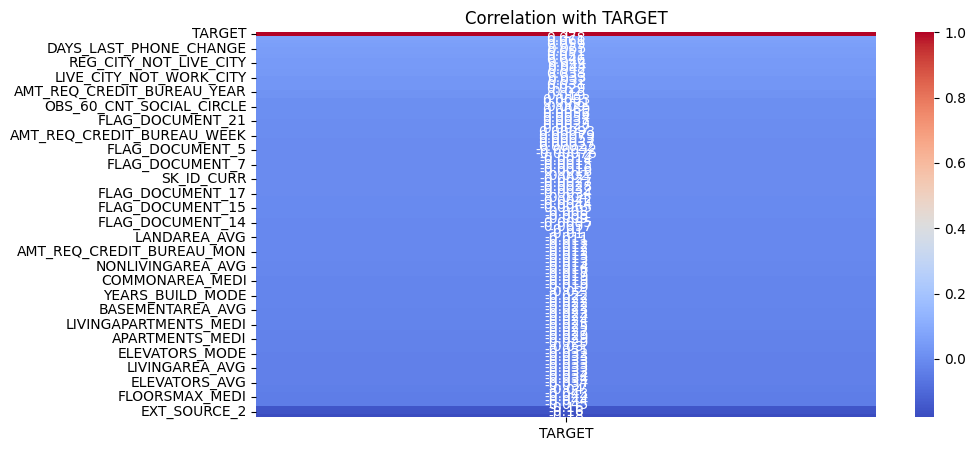

In [13]:
plt.figure(figsize=(10,5))

corr = application.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr[['TARGET']].sort_values(by='TARGET', ascending = False),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation with TARGET")
plt.show()

#### Feature Engineering

##### Credit to Income Ratio

In [14]:
application['CREDIT_INCOME_RATIO'] = (
    application['AMT_CREDIT'] /
    application['AMT_INCOME_TOTAL']
)

# -- higher ratio -> higher financial risk

##### Annuity to Income Ratio

In [15]:
application['ANNUITY_INCOME_RATIO'] = (
    application['AMT_ANNUITY'] /
    application['AMT_INCOME_TOTAL']
)

# -- Shows repayment burden

##### Credit Term

In [16]:
application['CREDIT_TERM'] = (
    application['AMT_ANNUITY'] /
    application['AMT_CREDIT']
)

# -- Represents effective loan duration/risk.

##### Employment Percentage

In [17]:
application['EMPLOYED_PERCENT'] = (
    application['DAYS_EMPLOYED'] /
    application['DAYS_BIRTH']
)

# -- Shows employment stability

##### Income Per Family Member

In [18]:
application['INCOME_PER_PERSON'] = (
    application['AMT_INCOME_TOTAL'] /
    application['CNT_FAM_MEMBERS']
)

# -- Captures household pressure

##### Age Feature

In [19]:
application['AGE'] = (
    abs(application['DAYS_BIRTH']) / 365
).astype(int)

# -- Dataset has negative value i.e it is taking 
# -- application date as reference point(Day 0)

##### Employment Years

In [20]:
# --This dataset has a strange value
application['DAYS_EMPLOYED'].replace(
    365243,
    np.nan,
    inplace=True
)

application['YEARS_EMPLOYED'] = (
    abs(application['DAYS_EMPLOYED']) / 365
)


##### External Score Average

In [21]:
ext_cols = [
    col for col in [
        'EXT_SOURCE_1',
        'EXT_SOURCE_2',
        'EXT_SOURCE_3'
    ]
    if col in application.columns
]

application['EXT_SOURCE_MEAN'] = (
    application[ext_cols].mean(axis=1)
)

# --These external scores are highly predictive.

##### Total Document Flags

In [22]:
# -- Find all document columns
doc_cols = [
    col for col in application.columns 
    if 'FLAG_DOC' in col
]

# -- Sum them meaning adding values row-wise
application['TOTAL_DOC_FLAGS'] = (
    application[doc_cols].sum(axis=1)
)

##### Total Enquiries

In [23]:
enquiry_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

application['TOTAL_ENQUIRIES'] = application[enquiry_cols].sum(axis=1)

#### Data Cleaning

##### Remove columns with high missing values

In [24]:
threshold = 50

missing_percent = (application.isnull().sum()/len(application))*100

drop_columns = missing_percent[missing_percent > threshold].index

application.drop(columns=drop_columns, inplace=True)

print("Dropped Columns :", len(drop_columns))

Dropped Columns : 41


##### Separate Numerical and Categorical Columns

In [25]:
numerical_cols = application.select_dtypes(include=np.number).columns.tolist()

categorical_cols = application.select_dtypes(include='object').columns.tolist()

##### Fill Missing Values

In [26]:
# Numerical
num_imputer = SimpleImputer(strategy='median')

application[numerical_cols] = num_imputer.fit_transform(
    application[numerical_cols]
)

# Categorical
cat_imputer = SimpleImputer(strategy='most_frequent')

application[categorical_cols] = cat_imputer.fit_transform(
    application[categorical_cols]
)

In [27]:
numerical_cols = application.select_dtypes(include=np.number).columns.tolist()

categorical_cols = application.select_dtypes(include='object').columns.tolist()

#### Encoding

In [28]:
# =========================
# Label Encoding
# =========================

le = LabelEncoder()

for col in categorical_cols:
    application[col] = le.fit_transform(application[col])

print("Categorical Encoding Completed")

Categorical Encoding Completed


#### Feature & Target Split

In [29]:
# =========================
# Features and Target
# =========================

X = application.drop('TARGET', axis=1)

y = application['TARGET']

print(X.shape)
print(y.shape)

(307511, 90)
(307511,)


#### Train Test Split

In [30]:
# =========================
# Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape : (246008, 90)
Test Shape : (61503, 90)


#### Handle Imbalanced Dataset

In [31]:
print("Missing Values:", X.isnull().sum().sum())

print("Infinite Values:",
      np.isinf(X.select_dtypes(include=np.number)).sum().sum())

Missing Values: 0
Infinite Values: 0


In [32]:
# =========================
# SMOTE Oversampling
# =========================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: TARGET
0.0    226148
1.0     19860
Name: count, dtype: int64
After SMOTE: TARGET
0.0    226148
1.0    226148
Name: count, dtype: int64


In [33]:
X.isnull().sum().sum()

np.int64(0)

#### Model Building

##### Logistic Regression

In [34]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_smote, y_train_smote)

lr_pred = lr_model.predict(X_test)

##### Decision Tree

In [35]:
dt_model = DecisionTreeClassifier(
    max_depth = 10,
    random_state = 42
)

dt_model.fit(X_train_smote, y_train_smote)

dt_pred = dt_model.predict(X_test)

##### Random Forest

In [36]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth = 15,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_test)

##### XGBoost

In [37]:
xgb_model = XGBClassifier(
    n_estimators = 100,
    max_depth = 7,
    learning_state = 0.1,
    random_state = 42,
    eval_metric = 'logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_test)

#### Evaluation

In [38]:
# =========================
# Model Evaluation Function
# =========================

def evaluate_model(y_test, predictions, model_name):

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\n========== {model_name} ==========")

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report\n")

    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"Confusion Matrix - {model_name}")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

##### Evaluate Models


========== Logistic Regression ==========
Accuracy : 0.6105555826545047
Precision: 0.11375564506285854
Recall   : 0.5631419939577039
F1 Score : 0.1892770105605199

Classification Report

              precision    recall  f1-score   support

         0.0       0.94      0.61      0.74     56538
         1.0       0.11      0.56      0.19      4965

    accuracy                           0.61     61503
   macro avg       0.53      0.59      0.47     61503
weighted avg       0.87      0.61      0.70     61503



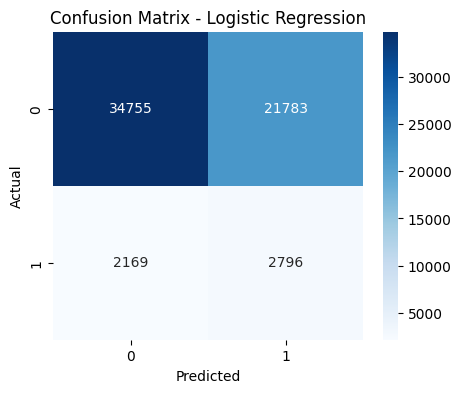

In [39]:
evaluate_model(y_test, lr_pred, "Logistic Regression")


========== Decision Tree ==========
Accuracy : 0.8886233191876819
Precision: 0.13426464881645325
Recall   : 0.06968781470292044
F1 Score : 0.09175285070273137

Classification Report

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94     56538
         1.0       0.13      0.07      0.09      4965

    accuracy                           0.89     61503
   macro avg       0.53      0.52      0.52     61503
weighted avg       0.86      0.89      0.87     61503



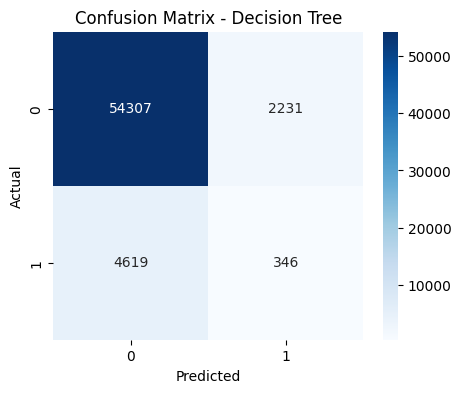

In [40]:
evaluate_model(y_test, dt_pred, "Decision Tree")


========== Random Forest ==========
Accuracy : 0.9095003495764434
Precision: 0.20853540252182348
Recall   : 0.0433031218529708
F1 Score : 0.07171447631754503

Classification Report

              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     56538
         1.0       0.21      0.04      0.07      4965

    accuracy                           0.91     61503
   macro avg       0.56      0.51      0.51     61503
weighted avg       0.86      0.91      0.88     61503



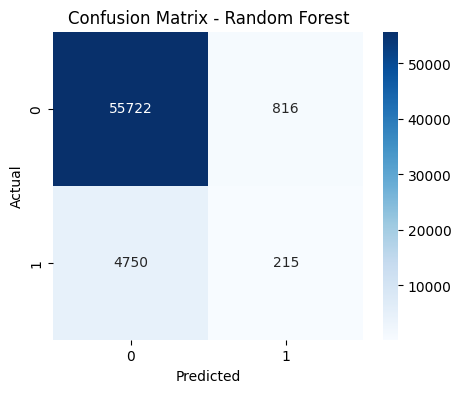

In [41]:
evaluate_model(y_test, rf_pred, "Random Forest")


========== Random Forest ==========
Accuracy : 0.9095003495764434
Precision: 0.20853540252182348
Recall   : 0.0433031218529708
F1 Score : 0.07171447631754503

Classification Report

              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     56538
         1.0       0.21      0.04      0.07      4965

    accuracy                           0.91     61503
   macro avg       0.56      0.51      0.51     61503
weighted avg       0.86      0.91      0.88     61503



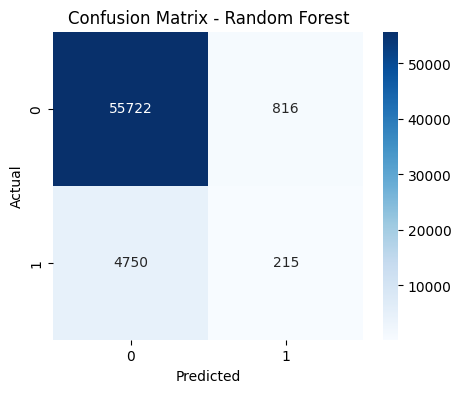

In [42]:
evaluate_model(y_test, rf_pred, "Random Forest")

#### Model Comparison

In [43]:
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]

})

results.sort_values(by='Recall', ascending=False)

,Model,Accuracy,Recall,F1 Score
0,Logistic Regression,0.610556,0.563142,0.189277
1,Decision Tree,0.888623,0.069688,0.091753
2,Random Forest,0.909500,0.043303,0.071714
3,XGBoost,0.918606,0.042699,0.078085


#### Summary

Logistic Regression achieved the highest recall and was better at identifying defaulters, making it more suitable for banking risk analysis. Although ensemble models such as Random Forest and XGBoost achieved higher accuracy, they showed poor recall for the minority class and failed to detect a significant number of risky customers.